<a href="https://colab.research.google.com/github/mbarcodia/msc204_enviro_stats/blob/main/seastars_signCI_mean_var.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Lady Elliot Island Sea Star Example
# A benthic survey collects 16 sea stars measured longest arm to the nearest 10th of a cm. Assume normality for this population.

### Confidence Interval for Population Mean (Small Sample, Unknown Population Standard Deviation)

Given a sample of size $n < 30$ and an unknown population standard deviation, we use the t-distribution to calculate the confidence interval for the population mean. The formula for the confidence interval is:

$$ \bar{x} \pm t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}} $$

Where:
* $ \bar{x} $ is the sample mean
* $ t_{\alpha/2, n-1} $ is the t-critical value for a given confidence level and degrees of freedom ($n-1$)
* $ s $ is the sample standard deviation
* $ n $ is the sample size

**L1 (Lower Bound):**

$$ L1 = \bar{x} - t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}} $$

**L2 (Upper Bound):**

$$ L2 = \bar{x} + t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}} $$

In [ ]:
# --- 1. Import necessary libraries ---
import numpy as np
from scipy import stats

# --- 2. State (or compute if needed) Sample Statistics ---
sample_mean = 11.00
sample_std = 1.63
sample_size = 16

# --- 3. Define Confidence Level and Degrees of Freedom ---
confidence_level = 0.95  # 95% confidence interval
alpha = 1 - confidence_level
degrees_of_freedom = sample_size - 1

print(f"Sample Mean (x̄): {sample_mean:.2f} cm")
print(f"Sample Standard Deviation (s): {sample_std:.2f} cm")
print(f"Sample Size (n): {sample_size}")
print(f"Degrees of Freedom (df): {degrees_of_freedom}")
print(f"Confidence Level: {confidence_level*100}%")
print("\n" + "="*50 + "\n")

Sample Mean (x̄): 11.00 cm
Sample Standard Deviation (s): 1.63 cm
Sample Size (n): 16
Degrees of Freedom (df): 15
Confidence Level: 95.0%




In [ ]:
# --- Version 1: Manually Inputting t-critical value ---
# For a 95% confidence interval and 15 degrees of freedom (n-1 = 16-1 = 15),
# the t-critical value (t_alpha/2, df) for a two-tailed test is ~2.131.
# You can find this value in a t-distribution table.

t_critical_manual = 2.131  # From t-distribution table for df=15, alpha/2=0.025

# Calculate Margin of Error
# ME = t_critical * (s / sqrt(n))
margin_of_error_manual = t_critical_manual * (sample_std / np.sqrt(sample_size))

# Calculate Confidence Interval Bounds
# L1 = x̄ - ME
lower_bound_manual = sample_mean - margin_of_error_manual
# L2 = x̄ + ME
upper_bound_manual = sample_mean + margin_of_error_manual

print("--- Confidence Interval (Manual t-critical) ---")
print(f"Manual t-critical value: {t_critical_manual:.3f}")
print(f"Margin of Error: {margin_of_error_manual:.2f} cm")
print(f"95% Confidence Interval (L1, L2): ({lower_bound_manual:.2f} cm, {upper_bound_manual:.2f} cm)")
print("\n" + "="*50 + "\n")

--- Confidence Interval (Manual t-critical) ---
Manual t-critical value: 2.131
Margin of Error: 0.87 cm
95% Confidence Interval (L1, L2): (10.13 cm, 11.87 cm)




In [ ]:
# --- Version 2: Using a library (scipy.stats) to find t-critical value ---
# The ppf (percent point function) or quantile function of the t-distribution
# gives the t-critical value for a given probability and degrees of freedom.
# For a two-tailed 95% CI, we need the value corresponding to (1 - alpha/2) = 0.975.

t_critical_library = stats.t.ppf(1 - alpha/2, degrees_of_freedom)

# Calculate Margin of Error
# ME = t_critical * (s / sqrt(n))
margin_of_error_library = t_critical_library * (sample_std / np.sqrt(sample_size))

# Calculate Confidence Interval Bounds
# L1 = x̄ - ME
lower_bound_library = sample_mean - margin_of_error_library
# L2 = x̄ + ME
upper_bound_library = sample_mean + margin_of_error_library

print("--- Confidence Interval (Library t-critical) ---")
print(f"Library t-critical value: {t_critical_library:.3f}")
print(f"Margin of Error: {margin_of_error_library:.2f} cm")
print(f"95% Confidence Interval (L1, L2): ({lower_bound_library:.2f} cm, {upper_bound_library:.2f} cm)")
print("\n" + "="*50 + "\n")

# --- Conclusion ---
print(f"We are {confidence_level*100}% confident that the true population mean arm length of sea stars on Lady Elliot Island")
print(f"falls between {lower_bound_library:.2f} cm and {upper_bound_library:.2f} cm.")

--- Confidence Interval (Library t-critical) ---
Library t-critical value: 2.131
Margin of Error: 0.87 cm
95% Confidence Interval (L1, L2): (10.13 cm, 11.87 cm)


We are 95.0% confident that the true population mean arm length of sea stars on Lady Elliot Island
falls between 10.13 cm and 11.87 cm.


In [ ]:
# --- Perform One-Sample t-test ---
# The null hypothesis (H0) is that the true population mean is 12 cm.
# The alternative hypothesis (Ha) is that the true population mean is NOT 12 cm (two-tailed test).

# Define the hypothesized population mean
mu_0 = 12.0  # Hypothesized mean in cm
alpha_ttest = 0.05 # Significance level for the t-test

print(f"Hypothesized Population Mean (μ_0): {mu_0} cm")
print(f"Significance Level (α): {alpha_ttest}")
print("\n" + "="*50 + "\n")

# Perform the one-sample t-test
# Note: ttest_1samp takes the sample data (sea_star_measurements) and the hypothesized mean.
# It returns the t-statistic and the two-tailed p-value.
# We will use the given info along with `sample_size` and `scipy.stats.t.cdf` to calculate the t-statistic and p-value.

# Calculate the t-statistic
standard_error_mean = sample_std / np.sqrt(sample_size)
t_statistic = (sample_mean - mu_0) / standard_error_mean

# Calculate the p-value for a two-tailed test
# The ppf (percent point function) is for critical values; cdf (cumulative distribution function) is for p-values.
# For a two-tailed test, the p-value is 2 * P(T < -|t_statistic|) or 2 * P(T > |t_statistic|).
# Using the cdf, it's 2 * stats.t.cdf(-abs(t_statistic), degrees_of_freedom)

p_value = 2 * stats.t.cdf(-np.abs(t_statistic), degrees_of_freedom)

print(f"Calculated t-statistic: {t_statistic:.3f}")
print(f"Calculated p-value: {p_value:.3f}")

# --- Interpret the results ---
if p_value < alpha_ttest:
    print(f"\nSince the p-value ({p_value:.3f}) is less than alpha ({alpha_ttest}), we reject the null hypothesis.")
    print(f"Conclusion: The sample mean ({sample_mean:.2f} cm) is significantly different from the hypothesized mean of {mu_0:.0f} cm.")
else:
    print(f"\nSince the p-value ({p_value:.3f}) is greater than or equal to alpha ({alpha_ttest}), we fail to reject the null hypothesis.")
    print(f"Conclusion: There is no significant difference between the sample mean ({sample_mean:.2f} cm) and the hypothesized mean of {mu_0:.0f} cm.")

Hypothesized Population Mean (μ_0): 12.0 cm
Significance Level (α): 0.05


Calculated t-statistic: -2.454
Calculated p-value: 0.027

Since the p-value (0.027) is less than alpha (0.05), we reject the null hypothesis.
Conclusion: The sample mean (11.00 cm) is significantly different from the hypothesized mean of 12 cm.


### Interpretation of the Arm Length Distribution Visualizations

*   **Histogram:** The histogram provides a visual representation of the frequency of different arm lengths. The `kde` (Kernel Density Estimate) line smooths out the distribution, giving an idea of the underlying probability density function. From the plot, we can observe the general shape of the distribution (e.g., symmetric, skewed, bimodal).

*   **Box Plot:** The box plot summarizes the distribution of the arm lengths based on five key numbers:
    *   **Minimum:** The smallest observation.
    *   **First Quartile (Q1):** 25% of the data falls below this value.
    *   **Median (Q2):** The middle value of the dataset, dividing it into two equal halves.
    *   **Third Quartile (Q3):** 75% of the data falls below this value.
    *   **Maximum:** The largest observation.
    *   **Whiskers:** Extend to the most extreme data points within 1.5 times the Interquartile Range (IQR = Q3 - Q1) from the box. Data points outside the whiskers are considered potential outliers and are plotted as individual points.

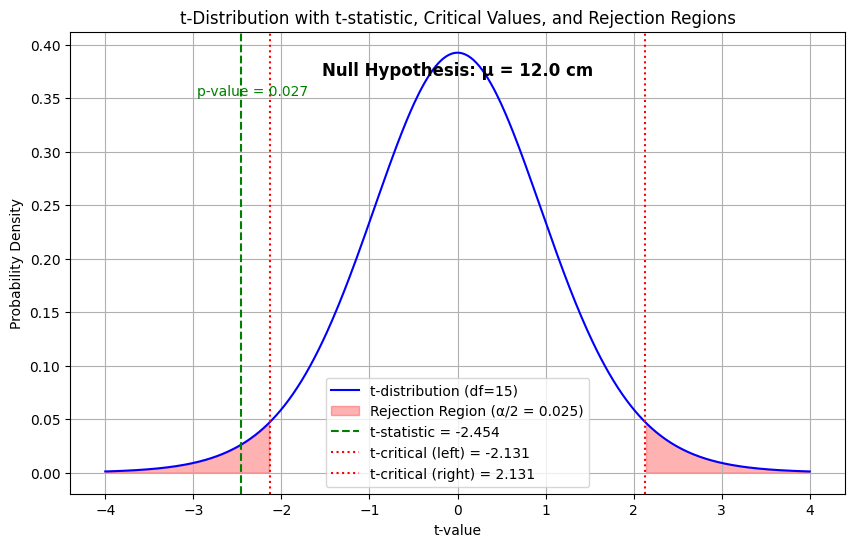

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# --- Visualize the t-test results ---

# Define the range for the t-distribution plot
x = np.linspace(-4, 4, 500)

# Calculate the probability density function (PDF) for the t-distribution
y = stats.t.pdf(x, degrees_of_freedom)

# Calculate the two-tailed t-critical values for alpha_ttest
t_critical_left = stats.t.ppf(alpha_ttest / 2, degrees_of_freedom)
t_critical_right = stats.t.ppf(1 - alpha_ttest / 2, degrees_of_freedom)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label=f't-distribution (df={degrees_of_freedom})', color='blue')

# Shade the rejection regions (alpha/2 in each tail)
x_reject_left = x[x < t_critical_left]
y_reject_left = y[x < t_critical_left]
plt.fill_between(x_reject_left, 0, y_reject_left, color='red', alpha=0.3, label=f'Rejection Region (α/2 = {alpha_ttest/2:.3f})')

x_reject_right = x[x > t_critical_right]
y_reject_right = y[x > t_critical_right]
plt.fill_between(x_reject_right, 0, y_reject_right, color='red', alpha=0.3)

# Plot the t-statistic
plt.axvline(t_statistic, color='green', linestyle='--', label=f't-statistic = {t_statistic:.3f}')

# Plot the t-critical values
plt.axvline(t_critical_left, color='red', linestyle=':', label=f't-critical (left) = {t_critical_left:.3f}')
plt.axvline(t_critical_right, color='red', linestyle=':', label=f't-critical (right) = {t_critical_right:.3f}')

# Add annotation for p-value (approximate location for clarity)
# Since p_value is 2 * P(T < -|t_statistic|), we can represent it visually.
plt.text(t_statistic - 0.5, 0.35, f'p-value = {p_value:.3f}', color='green', verticalalignment='bottom')
plt.text(0, plt.ylim()[1] * 0.9, f'Null Hypothesis: μ = {mu_0} cm', horizontalalignment='center', fontsize=12, fontweight='bold')

plt.title('t-Distribution with t-statistic, Critical Values, and Rejection Regions')
plt.xlabel('t-value')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

### Confidence Interval for Population Variance ($\sigma^2$)

To calculate the confidence interval for the population variance when the population standard deviation is unknown and the sample size is small, we use the chi-squared ($\chi^2$) distribution. The formula for the confidence interval is:

$$ \frac{(n-1)s^2}{\chi^2_{\alpha/2, n-1}} \le \sigma^2 \le \frac{(n-1)s^2}{\chi^2_{1-\alpha/2, n-1}} $$

Where:
*   $n$ is the sample size
*   $s^2$ is the sample variance (square of the sample standard deviation)
*   $\chi^2_{\alpha/2, n-1}$ is the chi-squared critical value for the upper tail, corresponding to an area of $\alpha/2$ in the right tail with $n-1$ degrees of freedom.
*   $\chi^2_{1-\alpha/2, n-1}$ is the chi-squared critical value for the lower tail, corresponding to an area of $1-\alpha/2$ (or $\alpha/2$ in the left tail) with $n-1$ degrees of freedom.

**Key Points:**
*   Notice the inversion: the upper critical value is used for the lower bound of the interval, and the lower critical value is used for the upper bound. This is because the chi-squared distribution is skewed, and we are dividing by the critical values.

### Interpreting the p-value with the t-Distribution Graph

This graph visually demonstrates what the p-value represents and how it relates to our decision to reject or fail to reject the null hypothesis.

1.  **The p-value (0.027) represents the *area* in the tails of the t-distribution that is as extreme as, or more extreme than, your observed t-statistic (-2.454).** Since this is a two-tailed test, this area is split between both tails. If you were to sum the area in the left tail beyond your t-statistic and the equivalent area in the right tail, that sum would be 0.027.

2.  **Compare the p-value to your significance level (alpha).** Our alpha is 0.05. The **red shaded regions** in the graph collectively represent this alpha (0.025 in the left tail + 0.025 in the right tail = 0.05).

3.  **Visual Decision Rule:**
    *   If the **p-value is less than alpha (0.027 < 0.05)**, it means the area representing your t-statistic's extremity is *smaller* than the area defined by your rejection regions. This visually translates to your **t-statistic falling *inside* one of the red shaded rejection regions**. As you can see, our green t-statistic line is firmly within the left red-shaded area.
    *   If the p-value were greater than or equal to alpha, the t-statistic line would fall outside the red rejection regions, leading us to fail to reject the null hypothesis.

In essence, the graph allows you to *see* that the green t-statistic line falls into a region (the red shaded area) that is considered statistically 'unlikely' if the null hypothesis were true, and the p-value quantifies just how unlikely that observation is. Because the p-value is small (less than alpha) and the t-statistic is in the rejection region, we have enough evidence to reject the null hypothesis.

In [ ]:
# --- Calculate Confidence Interval for Population Variance ---

# Sample variance (s^2)
sample_variance = sample_std**2

# Degrees of freedom (already defined as degrees_of_freedom)
# confidence_level (already defined as 0.95)
# alpha (already defined as 1 - confidence_level = 0.05)

# Calculate chi-squared critical values
# For the lower bound of the variance CI, we use the chi-squared value for alpha/2 in the right tail.
# This corresponds to stats.chi2.ppf(1 - alpha/2, df)
chi2_upper_critical = stats.chi2.ppf(1 - alpha/2, degrees_of_freedom)

# For the upper bound of the variance CI, we use the chi-squared value for 1 - alpha/2 in the right tail.
# This corresponds to stats.chi2.ppf(alpha/2, df)
chi2_lower_critical = stats.chi2.ppf(alpha/2, degrees_of_freedom)

print(f"Sample Variance (s^2): {sample_variance:.2f} cm^2")
print(f"Degrees of Freedom (df): {degrees_of_freedom}")
print(f"Alpha (α): {alpha:.2f}")
print(f"Chi-squared critical value for lower tail (χ²_{alpha/2:.3f}, {degrees_of_freedom}): {chi2_lower_critical:.3f}")
print(f"Chi-squared critical value for upper tail (χ²_{1-alpha/2:.3f}, {degrees_of_freedom}): {chi2_upper_critical:.3f}")
print("\n" + "="*50 + "\n")

# Calculate the confidence interval bounds for population variance
lower_bound_variance = (degrees_of_freedom * sample_variance) / chi2_upper_critical
upper_bound_variance = (degrees_of_freedom * sample_variance) / chi2_lower_critical

print("--- Confidence Interval for Population Variance ---")
print(f"95% Confidence Interval for Population Variance (σ²): ({lower_bound_variance:.2f} cm², {upper_bound_variance:.2f} cm²)")


Sample Variance (s^2): 2.66 cm^2
Degrees of Freedom (df): 15
Alpha (α): 0.05
Chi-squared critical value for lower tail (χ²_0.025, 15): 6.262
Chi-squared critical value for upper tail (χ²_0.975, 15): 27.488


--- Confidence Interval for Population Variance ---
95% Confidence Interval for Population Variance (σ²): (1.45 cm², 6.36 cm²)


### Interpretation of the Confidence Interval for Population Variance

The calculated 95% confidence interval for the population variance ($\sigma^2$) is **(1.45 cm², 6.36 cm²)**.

This means that based on our sample of 16 sea star arm measurements, we are 95% confident that the true variance of the arm lengths of all sea stars on Lady Elliot Island lies between 1.45 cm² and 6.36 cm².

In simpler terms:
*   The **variance** is a measure of how spread out the data is. A higher variance means the data points are more spread out from the mean, while a lower variance means they are clustered closer to the mean.
*   This interval gives us a range within which we expect the true variability (spread) of the sea star arm lengths in the entire population to fall, with 95% confidence.

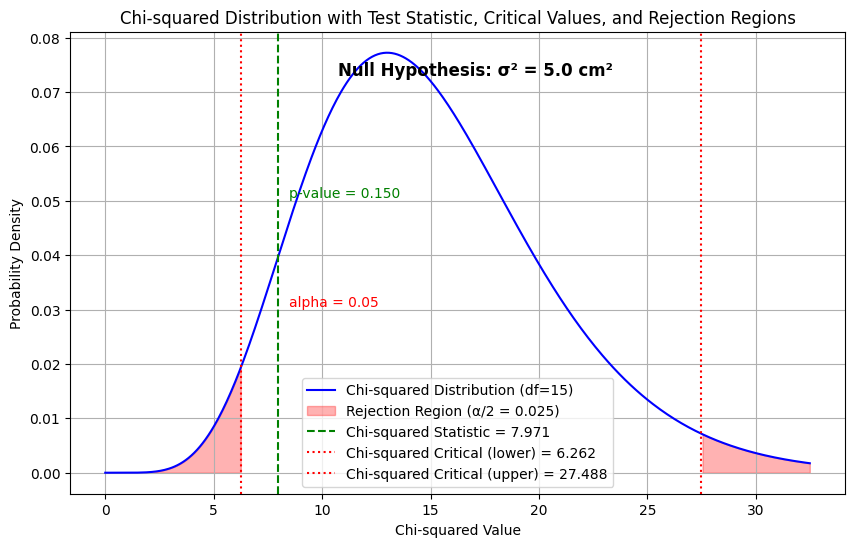

In [ ]:
import numpy as np
from scipy import stats

# --- Perform Chi-squared Test for Population Variance ---
# The null hypothesis (H0) is that the true population variance is 5.0 cm^2.
# The alternative hypothesis (Ha) is that the true population variance is NOT 5.0 cm^2 (two-tailed test).

# Define the hypothesized population variance
variance_h0 = 5.0  # Hypothesized variance in cm^2
alpha_chi2 = 0.05 # Significance level for the chi-squared test

print(f"Hypothesized Population Variance (σ²_0): {variance_h0} cm²")
print(f"Significance Level (α): {alpha_chi2}")
print("\n" + "="*50 + "\n")

# Calculate the chi-squared test statistic
# Formula: chi2_statistic = (n-1) * s^2 / sigma_0^2
chi2_statistic = (degrees_of_freedom * sample_variance) / variance_h0

# Calculate the p-value for a two-tailed test
# The p-value for a two-tailed chi-squared test is the sum of the areas in the tails.
# If the test statistic is less than the expected median (df), the p-value is 2 * P(X^2 < chi2_statistic).
# If the test statistic is greater, it's 2 * P(X^2 > chi2_statistic).

# More generally, p = 2 * min(stats.chi2.cdf(chi2_statistic, df), 1 - stats.chi2.cdf(chi2_statistic, df))
p_value_chi2 = 2 * min(stats.chi2.cdf(chi2_statistic, degrees_of_freedom), 1 - stats.chi2.cdf(chi2_statistic, degrees_of_freedom))

# Determine critical values for a two-tailed test
# For the lower tail
chi2_critical_lower = stats.chi2.ppf(alpha_chi2 / 2, degrees_of_freedom)
# For the upper tail
chi2_critical_upper = stats.chi2.ppf(1 - alpha_chi2 / 2, degrees_of_freedom)

print(f"Sample Variance (s²): {sample_variance:.2f} cm²")
print(f"Calculated Chi-squared Test Statistic: {chi2_statistic:.3f}")
print(f"Calculated p-value: {p_value_chi2:.3f}")
print(f"Chi-squared Critical (Lower): {chi2_critical_lower:.3f}")
print(f"Chi-squared Critical (Upper): {chi2_critical_upper:.3f}")

# --- Interpret the results ---
if p_value_chi2 < alpha_chi2:
    print(f"\nSince the p-value ({p_value_chi2:.3f}) is less than alpha ({alpha_chi2}), we reject the null hypothesis.")
    print(f"Conclusion: The sample variance ({sample_variance:.2f} cm²) is significantly different from the hypothesized variance of {variance_h0:.1f} cm².")
else:
    print(f"\nSince the p-value ({p_value_chi2:.3f}) is greater than or equal to alpha ({alpha_chi2}), we fail to reject the null hypothesis.")
    print(f"Conclusion: There is no significant difference between the sample variance ({sample_variance:.2f} cm²) and the hypothesized variance of {variance_h0:.1f} cm².")


Hypothesized Population Variance (σ²_0): 5.0 cm²
Significance Level (α): 0.05


Sample Variance (s²): 2.66 cm²
Calculated Chi-squared Test Statistic: 7.971
Calculated p-value: 0.150
Chi-squared Critical (Lower): 6.262
Chi-squared Critical (Upper): 27.488

Since the p-value (0.150) is greater than or equal to alpha (0.05), we fail to reject the null hypothesis.
Conclusion: There is no significant difference between the sample variance (2.66 cm²) and the hypothesized variance of 5.0 cm².


### Relationship between Confidence Intervals and Two-Tailed Hypothesis Tests

There is a direct relationship between a two-tailed hypothesis test and a confidence interval for the same parameter at the same significance level.

*   **If the hypothesized value (from the null hypothesis) falls *outside* the confidence interval, you will reject the null hypothesis.**
*   **If the hypothesized value falls *inside* the confidence interval, you will fail to reject the null hypothesis.**

In our case:
*   The **hypothesized population variance** (from the null hypothesis $H_0: \sigma^2 = 5.0 \text{ cm}^2$) is $5.0 \text{ cm}^2$.
*   The **95% confidence interval** for the population variance we calculated previously is **(1.45 cm², 6.36 cm²)**.

Since the hypothesized value of $5.0 \text{ cm}^2$ *falls within* the confidence interval (1.45 cm² to 6.36 cm²), we would expect to **fail to reject the null hypothesis** at the $0.05$ significance level. This aligns with the result of our chi-squared test, where we found that the p-value was greater than alpha, leading us to fail to reject the null hypothesis.

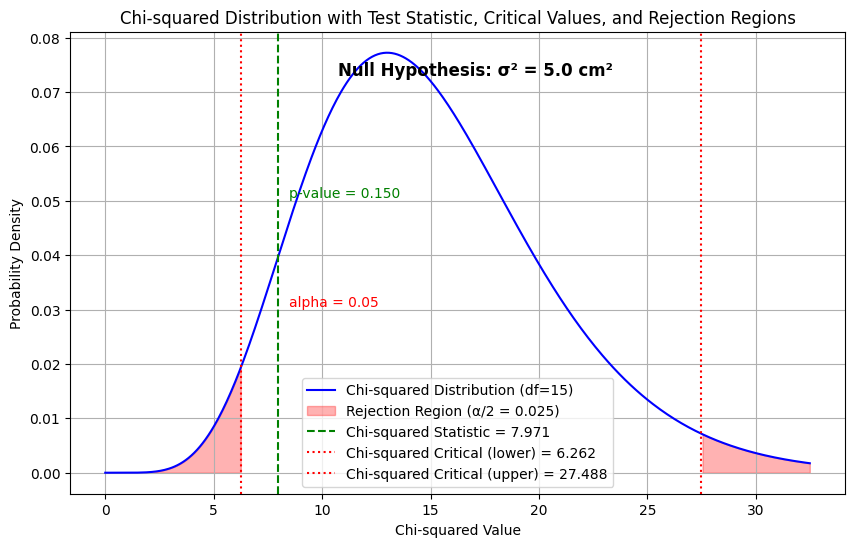

In [ ]:
# --- Visualize the Chi-squared Test Results ---

# Define the range for the chi-squared distribution plot
# The chi-squared distribution is always non-negative.
# A common rule of thumb for upper limit is df + 4*sqrt(2*df) or based on highest critical value/statistic.
# Let's use a range that covers our critical values and statistic.
x = np.linspace(0, max(chi2_critical_upper + 5, chi2_statistic + 5), 500)

# Calculate the probability density function (PDF) for the chi-squared distribution
y = stats.chi2.pdf(x, degrees_of_freedom)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label=f'Chi-squared Distribution (df={degrees_of_freedom})', color='blue')

# Shade the rejection regions (alpha/2 in each tail)
# Left tail
x_reject_left = x[x < chi2_critical_lower]
y_reject_left = y[x < chi2_critical_lower]
plt.fill_between(x_reject_left, 0, y_reject_left, color='red', alpha=0.3, label=f'Rejection Region (α/2 = {alpha_chi2/2:.3f})')

# Right tail
x_reject_right = x[x > chi2_critical_upper]
y_reject_right = y[x > chi2_critical_upper]
plt.fill_between(x_reject_right, 0, y_reject_right, color='red', alpha=0.3)

# Plot the chi-squared statistic
plt.axvline(chi2_statistic, color='green', linestyle='--', label=f'Chi-squared Statistic = {chi2_statistic:.3f}')

# Plot the chi-squared critical values
plt.axvline(chi2_critical_lower, color='red', linestyle=':', label=f'Chi-squared Critical (lower) = {chi2_critical_lower:.3f}')
plt.axvline(chi2_critical_upper, color='red', linestyle=':', label=f'Chi-squared Critical (upper) = {chi2_critical_upper:.3f}')

# Add annotation for p-value (approximate location for clarity)
# The p-value is the sum of the areas in the tails beyond the statistic.
# Since we fail to reject, the statistic is NOT in the rejection region, and the p-value area is larger than alpha.
plt.text(chi2_statistic + 0.5, 0.05, f'p-value = {p_value_chi2:.3f}', color='green', verticalalignment='bottom')
plt.text(chi2_statistic + 0.5, 0.03, f'alpha = {alpha_chi2:.2f}', color='red', verticalalignment='bottom')

plt.text(plt.xlim()[1] * 0.5, plt.ylim()[1] * 0.9, f'Null Hypothesis: σ² = {variance_h0} cm²', horizontalalignment='center', fontsize=12, fontweight='bold')

plt.title('Chi-squared Distribution with Test Statistic, Critical Values, and Rejection Regions')
plt.xlabel('Chi-squared Value')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()